**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd

# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

import define_params 

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

**Set the filepaths to the input and output data** 

In [2]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'
models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

**Set the parameters for this specific run**

In [3]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
exp_name = 'slope_lat_lon'
#exp_name = 'slope_front'
seed_nb = 1
this_collection = 'no_middle_5'
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

**Look at the model history to see how well it performed**

In [4]:
def load_history(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    fp_history = path_model + 'history_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.csv'
    if np.isin(fp_history, histories) == True:
        history = pd.read_csv(fp_history)
        if verbose == 1:
            print('\033[1m' + 'You have requested this model:' + '\033[0m')
            print(fp_model)
    else:
        if verbose == 1:   
            print('\033[1m' + 'The model you have requested does not exist.' + '\033[0m')
            print('\033[1m' + 'These models are currently available:' + '\033[0m')
            for i in range(len(models)):
                print(models[i])    
    return history

In [5]:
seed_nb_array = np.arange(1,11,1)
history_seeds = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
history_seeds2 = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
for i in seed_nb_array:
    history_seeds[i-1] = load_history('slope_lat_lon', 'no_middle_5', seed_nb = i, verbose = 0)
    history_seeds2[i-1] = load_history('slope_front', 'no_middle_5', seed_nb = i, verbose = 0)

In [6]:
def calculate_mean_std(history_seeds):
    cols = list(history_seeds[1])
    column_names = []
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        column_names.append(name_mean)
        column_names.append(name_std)
    df = pd.DataFrame(columns = column_names)
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        df[name_mean] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).mean(axis = 1)
        df[name_std] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).std(axis = 1)
    return df

In [7]:
df_lat_lon = calculate_mean_std(history_seeds)
df_front = calculate_mean_std(history_seeds2)


In [8]:
requested_param = 'loss' # 'loss', 'mae', 'mse'
if requested_param == 'mae':
    rp_label = 'Mean absolute error'
elif requested_param == 'loss':
    rp_label = 'Loss'
elif requested_param == 'mse':
    rp_label = 'Mean squared error'

In [9]:
rp_val = 'val_' + requested_param
rp_mean = requested_param + '_mean'
rp_std = requested_param + '_std'
rp_val_mean = 'val_' + requested_param + '_mean'
rp_val_std = 'val_' + requested_param + '_std'

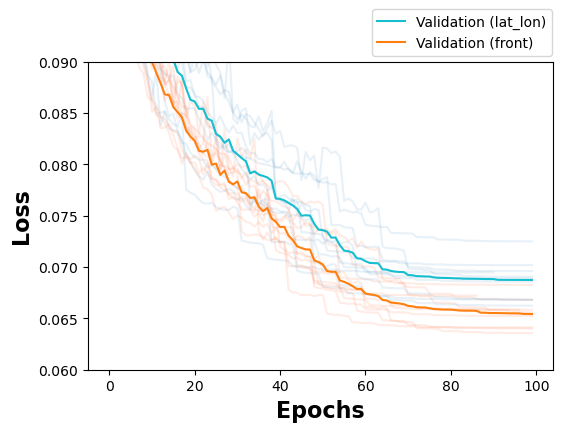

In [10]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for i in range(10):
    #ax.plot(history_seeds[i][requested_param], color = 'C9', alpha = 0.1)
    ax.plot(history_seeds[i][rp_val], color = 'C0', alpha = 0.1)
    #ax.plot(history_seeds2[i][requested_param], color = 'C1', alpha = 0.1)
    ax.plot(history_seeds2[i][rp_val], color = 'orangered', alpha = 0.1)
std_f = 1
df = df_lat_lon
#ax.plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
ax.plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

df = df_front
#ax.plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
ax.plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')

fontsize = 16
ax.set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
ax.set_ylabel(rp_label, fontsize = fontsize, weight = 'bold')
ax.legend(fontsize = fontsize-6, markerscale = 2, loc = (0.61, 1.02))
if requested_param == 'mae':
    ax.set_ylim(None, 0.15)
elif requested_param == 'loss':
    ax.set_ylim(0.06,0.09)
elif requested_param == 'mse':
    ax.set_ylim(0.06,0.09)

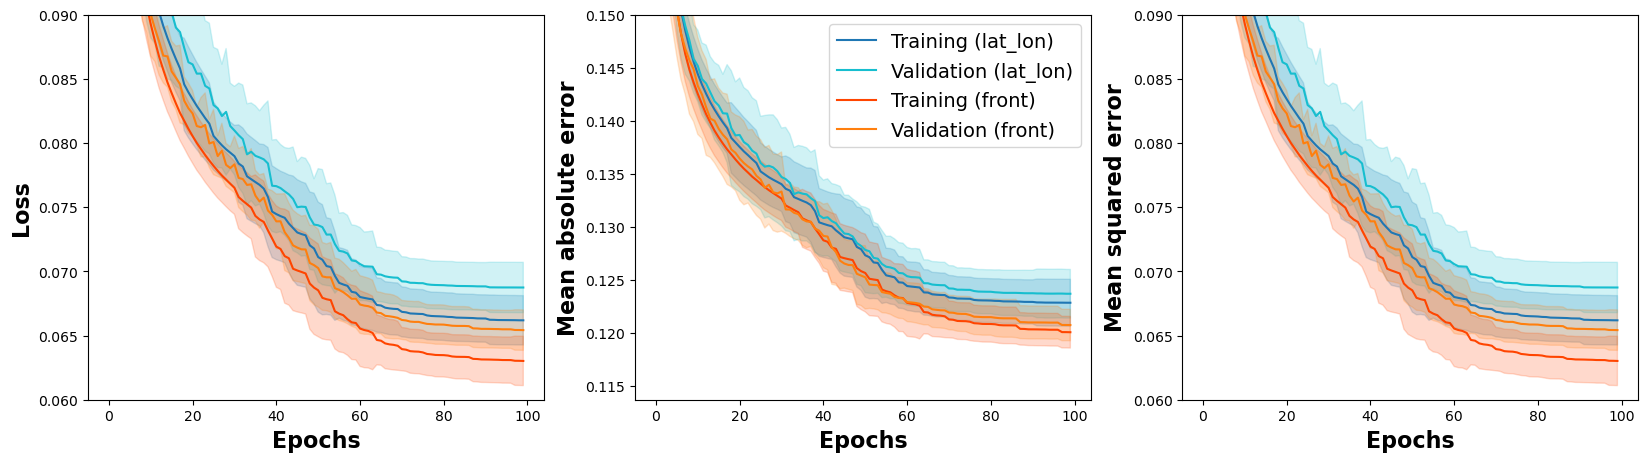

In [11]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
requested_parameters = ('loss', 'mae', 'mse')
labels = ('Loss', 'Mean absolute error', 'Mean squared error')
ylims = ((0.06,0.09), (None, 0.15), (0.06,0.09))
std_f = 1
fontsize = 16
for i in range(len(requested_parameters)):
    requested_param = requested_parameters[i]
    rp_val = 'val_' + requested_param
    rp_mean = requested_param + '_mean'
    rp_std = requested_param + '_std'
    rp_val_mean = 'val_' + requested_param + '_mean'
    rp_val_std = 'val_' + requested_param + '_std'
    df = df_lat_lon
    ax[i].plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
    ax[i].plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

    df = df_front
    ax[i].plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
    ax[i].plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')


    #ax[i].plot(df[rp_mean], label = 'Training')
    #ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2)
    #ax[i].plot(df[rp_val_mean], label = 'Validation')
    #ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2)
    fontsize = 16
    ax[i].set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
    ax[i].set_ylabel(labels[i], fontsize = fontsize, weight = 'bold')
    ax[i].set_ylim(ylims[i])
ax[1].legend(fontsize = fontsize-2, markerscale = 2)
    

### **Apply a trained nn to the test data set**

Create functions to:
- Load in the test data
- Load in the neural network model
- Load in the normalisation metrics for the training/validation dataset used to train the model
- Apply the neural network model to the normalised test data

In [12]:
# Load in all the data
def load_test_data(this_collection, verbose = 0):
    df_total = pd.read_csv(fp_all_data)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_all_data)
    
    months_mask, years_mask = define_params.month_year_by_collection(this_collection, title = False)
    months_mask_all, years_mask_all = define_params.month_year_by_collection('whole_dataset', title = False)
    
    if np.sum(~np.isin(df_total.month, months_mask)) != 0 & np.sum(~np.isin(df_total.year, years_mask)) != 0:
        print('Some months and some years were left out for testing and I don\'t know how to deal with this')
        print('Please help')
    elif np.sum(~np.isin(df_total.month, months_mask)) != 0:
        df_sel = df_total[~np.isin(df_total.month, months_mask)]
        if verbose == 1:
            print('\033[1m' + 'You have selected part of this dataset:' + '\033[0m')
            print('Selected by month')
    elif np.sum(~np.isin(df_total.year, years_mask)) != 0:
        df_sel = df_total[~np.isin(df_total.year, years_mask)]
        if verbose > 0:
            print('\033[1m' + 'You have selected part of this dataset:' + '\033[0m')
            print('Selected by year: ' + this_collection)
    # Convert imported data to xarray
    clean_df = df_sel.to_xarray()
    return clean_df

In [13]:
# Set the model filepath and load the normalisation metrics 
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model
    
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

In [14]:
def apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = pp.normalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

In [15]:
def apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
    clean_df = load_test_data(this_collection, verbose = verbose)
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                                'lon': clean_df.lon,
                                'basin': clean_df.basins_NEMO,
                                'area': clean_df.approx_area,
                                'year': clean_df.year, 
                                'month': clean_df.month, 
                                'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
        else:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 0) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values
    
    # If you want to make the files smaller, you can save the results with just the ensemble mean
    # by setting keep_all_runs to False 
    if keep_all_runs == False:
        df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
        print('Warning, you have not saved the results of each nn, just the ensemble mean')
        sims = 'just_mean'
    else:
        df_ref_pred_save = df_ref_pred
        print('You have saved the results of each nn, and the ensemble mean')
        sims = 'all_sims'
    # Set the filepath and save the output
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                        + sims + '_' + TS_opt + '_' + norm_method + '.csv'
    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

**Apply the neural network to the test data (aka data not used for training)**

In [16]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = False
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

No neural network applied, change apply_nn to True if desired


In [58]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
keep_all_runs = True
verbose = 2

norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
clean_df = load_test_data(this_collection, verbose = verbose)

You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/no_middle_5_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have selected part of this dataset:
Selected by year: no_middle_5


In [ ]:
keep_all_runs = True, \
                     mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
clean_df = load_test_data(this_collection, verbose = verbose)
seed_nb_array = np.arange(1,11,1)
list_melt_seeds = []
df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                            'lon': clean_df.lon,
                            'basin': clean_df.basins_NEMO,
                            'area': clean_df.approx_area,
                            'year': clean_df.year, 
                            'month': clean_df.month, 
                            'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
for i in range(len(seed_nb_array)):
    list_melt_seeds.append('melt_' + str(i+1).zfill(2))
    if verbose == 2:
        model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                          mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                          verbose = 1) 
        df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
    else:
        model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                          mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                          verbose = 0) 
        df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
# Calculate the ensemble mean 
df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values

# If you want to make the files smaller, you can save the results with just the ensemble mean
# by setting keep_all_runs to False 
if keep_all_runs == False:
    df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
    print('Warning, you have not saved the results of each nn, just the ensemble mean')
    sims = 'just_mean'
else:
    df_ref_pred_save = df_ref_pred
    print('You have saved the results of each nn, and the ensemble mean')
    sims = 'all_sims'
# Set the filepath and save the output
fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + sims + '_' + TS_opt + '_' + norm_method + '.csv'
df_ref_pred.to_csv(fp_ref_pred, index = False)

In [17]:
this_collection = 'no_jun_dec'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = False
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

No neural network applied, change apply_nn to True if desired


In [18]:
this_collection = 'no_mar_oct'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = False
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

No neural network applied, change apply_nn to True if desired


In [19]:
this_collection = 'up_to_2018'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = False
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

No neural network applied, change apply_nn to True if desired


In [20]:
this_collection = 'after_1984'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = False
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

No neural network applied, change apply_nn to True if desired


### **Start here if you want to look at results which have already been processed**

In [21]:
def load_results_nn(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    if keep_all_runs == False:
        sims = 'just_mean'
    else:
        sims = 'all_sims'
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                        + sims + '_' + TS_opt + '_' + norm_method + '.csv'
    df_ref_pred = pd.read_csv(fp_ref_pred)
    if verbose == 1:
        print('\033[1m' + 'You have loaded the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)
    return df_ref_pred

from sklearn.linear_model import LinearRegression as regres
# Linear regression model creation and fitting
def regression_analysis(ref_melt, pred_melt):
    ref_melt = ref_melt.values.reshape(-1,1)
    pred_melt = pred_melt.values.reshape(-1,1)
    model = regres()
    reg = model.fit(ref_melt, pred_melt)
    slope = reg.coef_[0][0] 
    intercept = reg.intercept_[0]
    rsq = reg.score(ref_melt, pred_melt)
    return slope, intercept, rsq

In [22]:
# To import the results for 
#this_collection = 'up_to_2018'
#exp_name = 'slope_front'
#ref_pred = load_results_nn(this_collection, exp_name)
#slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])

**Looking at just the overall scatter regression product**

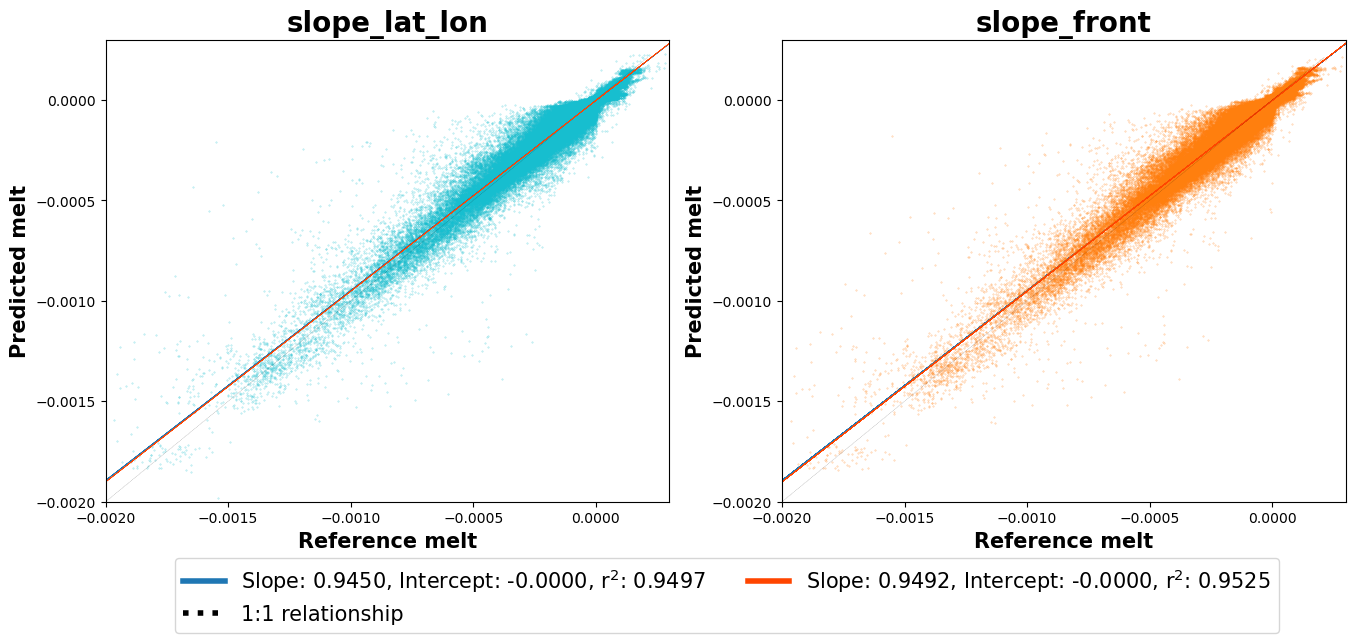

In [23]:
fig, ax = plt.subplots(1,2, figsize = (16,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(2):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
                zorder = 1, color = colors[1], linewidth = 0.4, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(exp_name, fontweight = 'bold', fontsize = 20)
#titles = [']
plot_scatter_label('no_middle_5', 'slope_lat_lon', ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_middle_5', 'slope_front', ax, ax[1], colors = ('C1', 'orangered'))

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[1].legend(flip(handles, 2), flip(labels, 2), ncol=2, markerscale = 20, bbox_to_anchor=[0.9, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

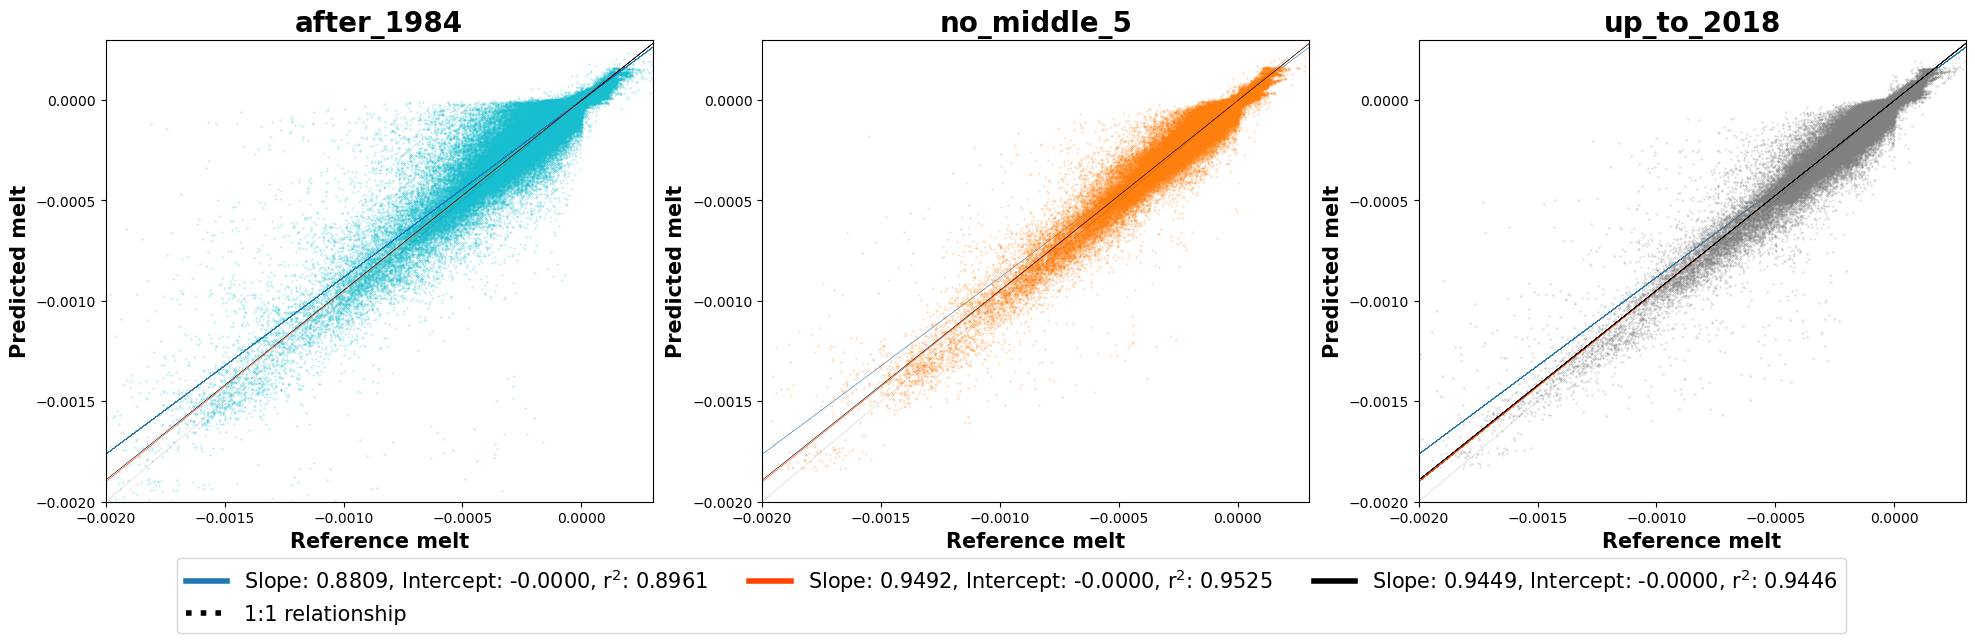

In [24]:
fig, ax = plt.subplots(1,3, figsize = (24,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(3):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
        zorder = 1, color = colors[1], linewidth = 0.2, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(this_collection, fontweight = 'bold', fontsize = 20)
#titles = [']
exp_name = 'slope_front'
plot_scatter_label('after_1984', exp_name, ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_middle_5', exp_name, ax, ax[1], colors = ('C1', 'orangered'))
plot_scatter_label('up_to_2018', exp_name, ax, ax[2], colors = ('grey', 'black'))

#leg = ax[2].legend(markerscale = 20, bbox_to_anchor=[1.02, -0.1], loc = 'upper right', fontsize = 15, ncol = 4)
## set the linewidth of each legend object
#for legobj in leg.legend_handles:
#    legobj.set_linewidth(4.0)

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[2].legend(flip(handles, 2), flip(labels, 2), ncol=3, markerscale = 20, bbox_to_anchor=[0.8, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

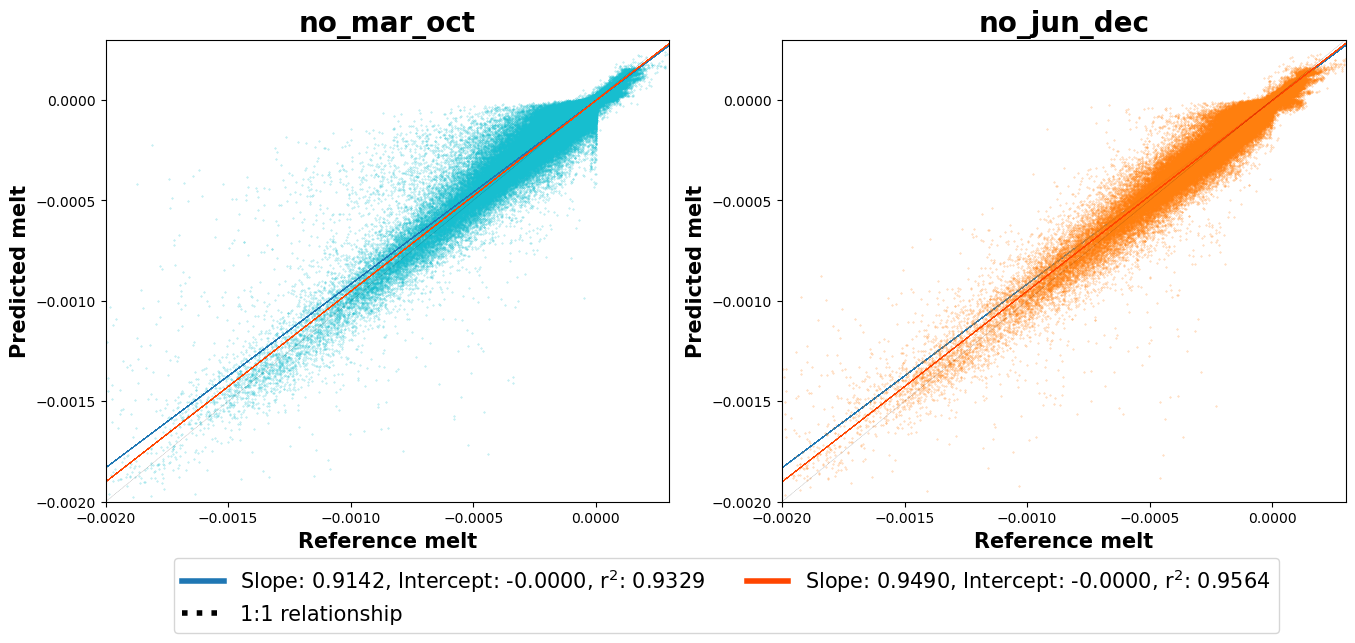

In [25]:
fig, ax = plt.subplots(1,2, figsize = (16,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(2):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
                zorder = 1, color = colors[1], linewidth = 0.4, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(this_collection, fontweight = 'bold', fontsize = 20)
#titles = [']
plot_scatter_label('no_mar_oct', 'slope_front', ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_jun_dec', 'slope_front', ax, ax[1], colors = ('C1', 'orangered'))

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[1].legend(flip(handles, 2), flip(labels, 2), ncol=2, markerscale = 20, bbox_to_anchor=[0.9, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

In [26]:
# To import the results for 
this_collection = 'up_to_2018'
this_collection = 'after_1984'
this_collection = 'no_middle_5'
#this_collection = 'no_jun_dec'
#this_collection = 'no_mar_oct'
exp_name = 'slope_front'
ref_pred = load_results_nn(this_collection, exp_name)
density_ice = 1 # kg/m3
ref_pred.loc[:,'melt_Gt_per_yr'] = ((ref_pred.loc[:,'melt_m_ice_per_y'] * ref_pred.loc[:,'area']* 31536000) * density_ice/1e12)
ref_pred.loc[:,'melt_pred_Gt'] = ((ref_pred.loc[:,'melt_pred_mean'] * ref_pred.loc[:,'area'] * 31536000) * density_ice/1e12)
#slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])

In [27]:
print('Total predicted melt: {:.0f} Gt'.format(ref_pred.sum().melt_Gt_per_yr/12))
print('Total reference melt: {:.0f} Gt'.format(ref_pred.sum().melt_pred_Gt/12))
print('Predicting {:.1f} % of reference melt'.format(ref_pred.sum().melt_pred_Gt*100/ref_pred.sum().melt_Gt_per_yr))

Total predicted melt: -4373 Gt
Total reference melt: -4469 Gt
Predicting 102.2 % of reference melt


In [28]:
years = np.linspace(1979, 2023, 45)
years_str = []
for i in range(len(years)):
    if np.mod(years[i],5) == 0:
        years_str.append(str(int(years[i])))
        years_str.append('')
        years_str.append('')
        years_str.append('')
        years_str.append('')

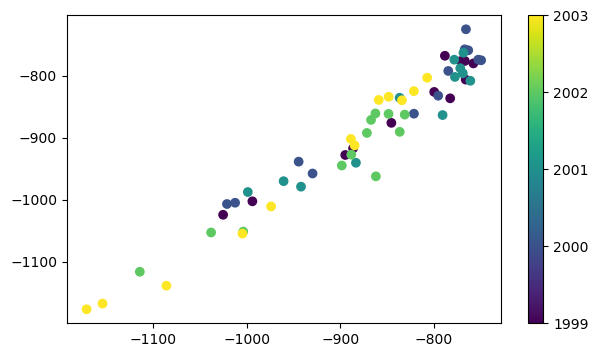

In [29]:
ref_ym = ref_pred.groupby(['year','month']).sum()
ym = list(ref_pred.groupby(['year','month']).groups)
yrs = []
for i in range(len(ym)):
    yrs.append(ym[i][0])
fig, ax = plt.subplots(1,1, figsize = (7,4))
plt.scatter(ref_ym.melt_Gt_per_yr.values, ref_ym.melt_pred_Gt.values, c = yrs)
#plt.legend(loc = (0.78,1.02))
cbar = plt.colorbar()
cbar.set_ticks((1999,2000,2001,2002,2003))

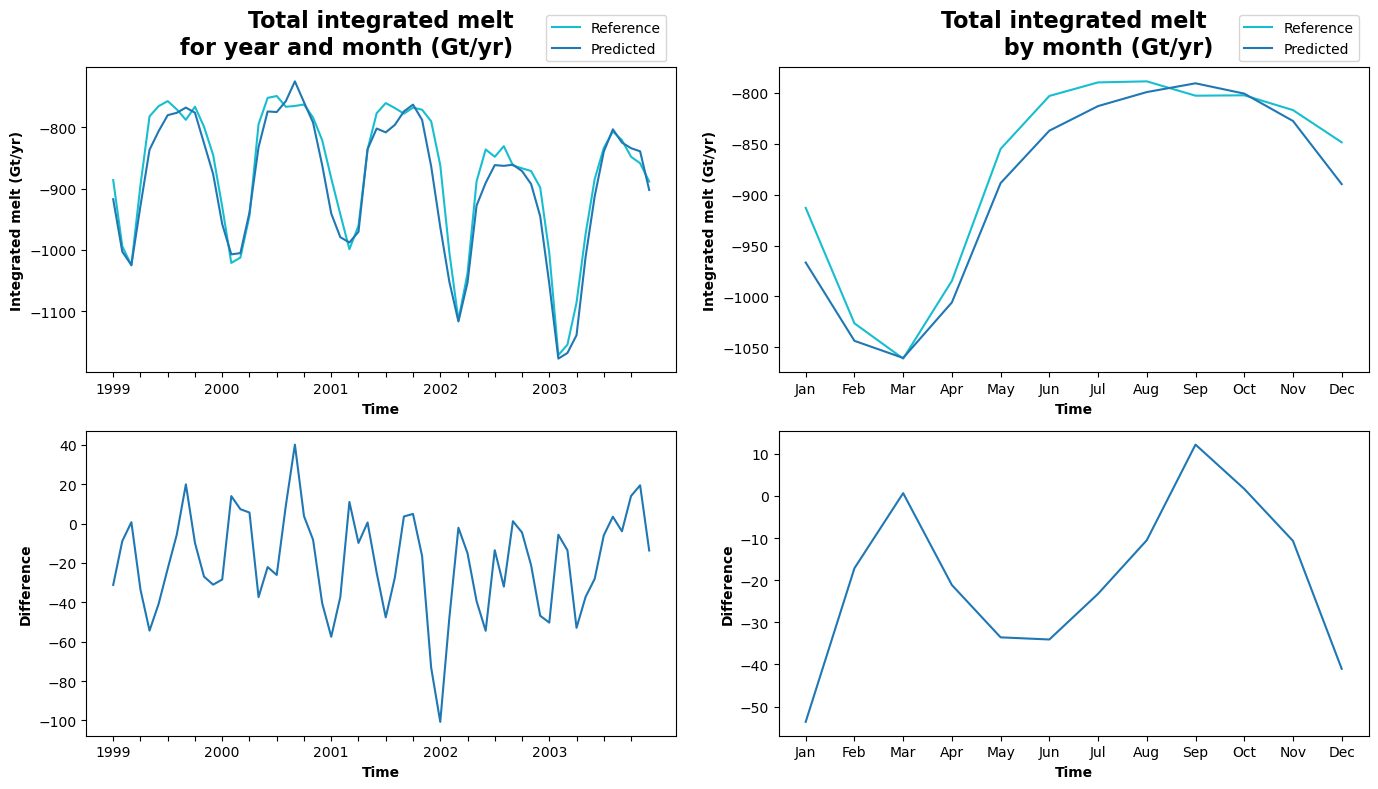

In [30]:
fig, ax_all = plt.subplots(2,2, figsize = (14,8))

ref_ym = ref_pred.groupby(['year','month']).sum()

ax = ax_all[0,0]
ax.plot(ref_ym.melt_Gt_per_yr.values, c = 'C9', label = 'Reference')
ax.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
ax.legend(loc = (0.78,1.02))
ax.set_ylabel('Integrated melt (Gt/yr)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
ax.set_title('Total integrated melt\nfor year and month (Gt/yr)         ', fontweight = 'bold', fontsize = 16, pad = 10) 

ax = ax_all[1,0]
ax.plot(ref_ym.melt_pred_Gt.values - ref_ym.melt_Gt_per_yr.values, c = 'C0')
#ax.axhline(y=100, zorder = 0, alpha = 0.5, color = 'grey')
ax.set_ylabel('Difference', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
#ax.set_title('Predicted melt\nas a percentage of reference melt', fontweight = 'bold', fontsize = 16, pad = 10) 
#ax.annotate('Applying nn to {}\nTotal predicted melt: {:.3f} Gt\nTotal reference melt: {:.3f} Gt\nPredicting {:.1f} % of reference melt'.format(\
#        this_collection,\
#       ref_pred.sum().melt_Gt_per_yr/12, \
#        ref_pred.sum().melt_pred_Gt/12, \
#         ref_pred.sum().melt_pred_Gt*100/ref_pred.sum().melt_Gt_per_yr), xy = (0.8,0.8), xytext = (0.5,0.05), xycoords = 'axes fraction')

for i in range(2):
    ax = ax_all[i,0]
    if this_collection == 'up_to_2018':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
    elif this_collection == 'after_1984':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('1979', '', '','', '1980', '', '','', '1981', '', '','', '1982', '', '','', '1983', '', '',''));
    elif this_collection == 'no_middle_5':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('1999', '', '','', '2000', '', '','', '2001', '', '','', '2002', '', '','', '2003', '', '',''));
    elif this_collection in ('no_mar_oct', 'no_jun_dec'):
        ticks = np.arange(0,90,2)
        ax.set_xticks(ticks)
        ax.set_xticklabels(years_str)

if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    ref_ym = ref_pred.groupby(['month']).sum()
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    ref_ym = ref_pred.groupby(['year']).sum()

ax = ax_all[0,1]
ax.plot(ref_ym.melt_Gt_per_yr.values/5, c = 'C9', label = 'Reference')
ax.plot(ref_ym.melt_pred_Gt.values/5, c = 'C0', label = 'Predicted')
ax.legend(loc = (0.78,1.02))
ax.set_ylabel('Integrated melt (Gt/yr)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    ax.set_title('Total integrated melt\n         by month (Gt/yr)', fontweight = 'bold', fontsize = 16, pad = 10) 
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
        ax.set_title('Total integrated melt\n        by year (Gt/yr)    ', fontweight = 'bold', fontsize = 16, pad = 10) 

ax = ax_all[1,1]
ax.plot(ref_ym.melt_pred_Gt.values/5- ref_ym.melt_Gt_per_yr.values/5, c = 'C0')
#ax.axhline(y=100, zorder = 0, alpha = 0.5, color = 'grey')
ax.set_ylabel('Difference', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
#ax.set_title('Predicted melt\nas a percentage of reference melt', fontweight = 'bold', fontsize = 16, pad = 10)

#if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
#    years = np.unique(ref_pred.year)
#    for i in range(len(years)):
#        year = years[i]
#        melt_by_month_yr = ref_pred.where(ref_pred.year == year).groupby(['month']).sum()
#        plt.plot(np.arange(0,12,1),(melt_by_month_yr.melt_pred_Gt/melt_by_month_yr.melt_Gt_per_yr)*100, color = 'C0', alpha = 0.2)
#elif this_collection in ('no_mar_oct', 'no_jun_dec'):
#    months = np.unique(ref_pred.month)
#    for i in range(len(months)):
#        month = months[i]
#        melt_by_year_mn = ref_pred.where(ref_pred.month == month).groupby(['year']).sum()
#        plt.plot(np.arange(0,45,1),(melt_by_year_mn.melt_pred_Gt/melt_by_year_mn.melt_Gt_per_yr)*100, color = 'C0', alpha = 0.2)

months_names = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')
if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    for i in range(2):
        ax = ax_all[i,1]
        ticks = np.arange(0,12,1)
        ax.set_xticks(ticks)
        ax.set_xticklabels(months_names)
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    for i in range(2):
        ax = ax_all[i,1]
        ticks = np.arange(0,45,1)
        ax.set_xticks(ticks)
        ax.set_xticklabels(years_str)

fig.tight_layout()

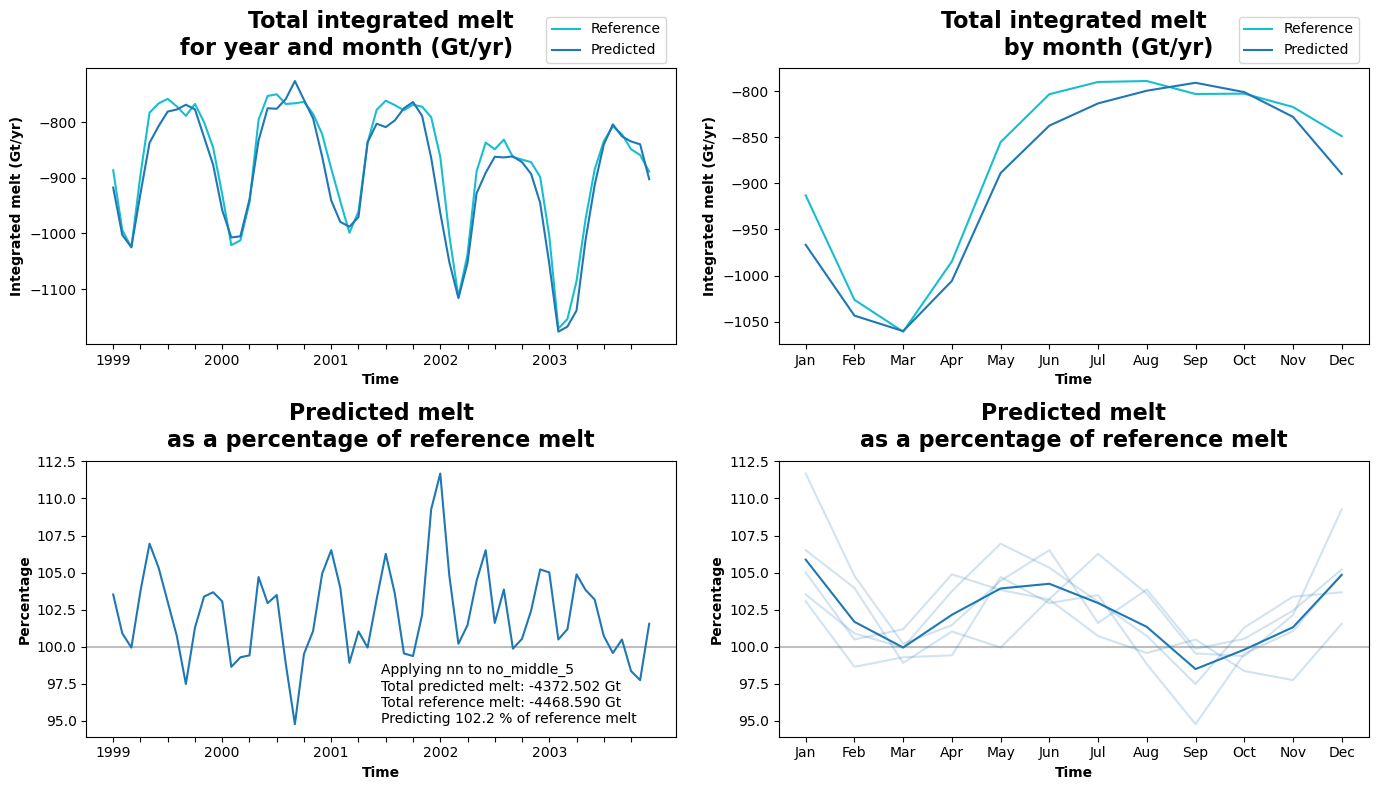

In [31]:
fig, ax_all = plt.subplots(2,2, figsize = (14,8))

ref_ym = ref_pred.groupby(['year','month']).sum()

ax = ax_all[0,0]
ax.plot(ref_ym.melt_Gt_per_yr.values, c = 'C9', label = 'Reference')
ax.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
ax.legend(loc = (0.78,1.02))
ax.set_ylabel('Integrated melt (Gt/yr)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
ax.set_title('Total integrated melt\nfor year and month (Gt/yr)         ', fontweight = 'bold', fontsize = 16, pad = 10) 

ax = ax_all[1,0]
ax.plot(ref_ym.melt_pred_Gt.values*100/ref_ym.melt_Gt_per_yr.values, c = 'C0')
ax.axhline(y=100, zorder = 0, alpha = 0.5, color = 'grey')
ax.set_ylabel('Percentage', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
ax.set_title('Predicted melt\nas a percentage of reference melt', fontweight = 'bold', fontsize = 16, pad = 10) 
ax.annotate('Applying nn to {}\nTotal predicted melt: {:.3f} Gt\nTotal reference melt: {:.3f} Gt\nPredicting {:.1f} % of reference melt'.format(\
        this_collection,\
       ref_pred.sum().melt_Gt_per_yr/12, \
        ref_pred.sum().melt_pred_Gt/12, \
         ref_pred.sum().melt_pred_Gt*100/ref_pred.sum().melt_Gt_per_yr), xy = (0.8,0.8), xytext = (0.5,0.05), xycoords = 'axes fraction')

for i in range(2):
    ax = ax_all[i,0]
    if this_collection == 'up_to_2018':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
    elif this_collection == 'after_1984':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('1979', '', '','', '1980', '', '','', '1981', '', '','', '1982', '', '','', '1983', '', '',''));
    elif this_collection == 'no_middle_5':
        ticks = np.arange(0,60,3)
        ax.set_xticks(ticks)
        ax.set_xticklabels(('1999', '', '','', '2000', '', '','', '2001', '', '','', '2002', '', '','', '2003', '', '',''));
    elif this_collection in ('no_mar_oct', 'no_jun_dec'):
        ticks = np.arange(0,90,2)
        ax.set_xticks(ticks)
        ax.set_xticklabels(years_str)

if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    ref_ym = ref_pred.groupby(['month']).sum()
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    ref_ym = ref_pred.groupby(['year']).sum()

ax = ax_all[0,1]
ax.plot(ref_ym.melt_Gt_per_yr.values/5, c = 'C9', label = 'Reference')
ax.plot(ref_ym.melt_pred_Gt.values/5, c = 'C0', label = 'Predicted')
ax.legend(loc = (0.78,1.02))
ax.set_ylabel('Integrated melt (Gt/yr)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    ax.set_title('Total integrated melt\n         by month (Gt/yr)', fontweight = 'bold', fontsize = 16, pad = 10) 
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    ax.set_title('Total integrated melt\n        by year (Gt/yr)    ', fontweight = 'bold', fontsize = 16, pad = 10) 

ax = ax_all[1,1]
ax.plot(ref_ym.melt_pred_Gt.values*100/ref_ym.melt_Gt_per_yr.values, c = 'C0')
ax.axhline(y=100, zorder = 0, alpha = 0.5, color = 'grey')
ax.set_ylabel('Percentage', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')
ax.set_title('Predicted melt\nas a percentage of reference melt', fontweight = 'bold', fontsize = 16, pad = 10)

if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    years = np.unique(ref_pred.year)
    for i in range(len(years)):
        year = years[i]
        melt_by_month_yr = ref_pred.where(ref_pred.year == year).groupby(['month']).sum()
        plt.plot(np.arange(0,12,1),(melt_by_month_yr.melt_pred_Gt/melt_by_month_yr.melt_Gt_per_yr)*100, color = 'C0', alpha = 0.2)
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    months = np.unique(ref_pred.month)
    for i in range(len(months)):
        month = months[i]
        melt_by_year_mn = ref_pred.where(ref_pred.month == month).groupby(['year']).sum()
        plt.plot(np.arange(0,45,1),(melt_by_year_mn.melt_pred_Gt/melt_by_year_mn.melt_Gt_per_yr)*100, color = 'C0', alpha = 0.2)

months_names = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')
if this_collection in ('no_middle_5', 'after_1984', 'up_to_2018'):
    for i in range(2):
        ax = ax_all[i,1]
        ticks = np.arange(0,12,1)
        ax.set_xticks(ticks)
        ax.set_xticklabels(months_names)
elif this_collection in ('no_mar_oct', 'no_jun_dec'):
    for i in range(2):
        ax = ax_all[i,1]
        ticks = np.arange(0,45,1)
        ax.set_xticks(ticks)
        ax.set_xticklabels(years_str)

fig.tight_layout()

In [32]:
basins = np.unique(ref_pred.basin)

Text(0.5, 0, 'Time')

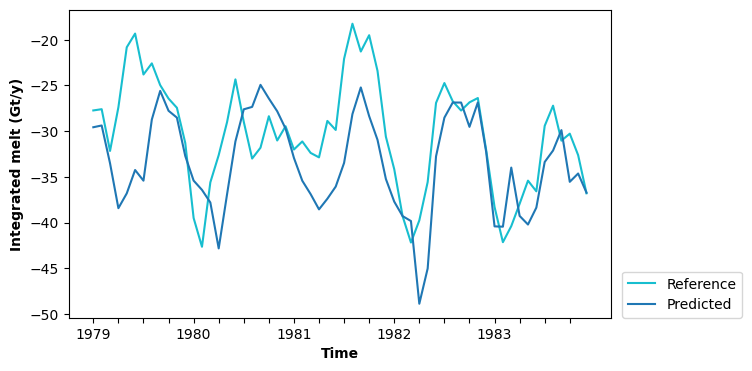

In [33]:
fig, ax = plt.subplots(1,1, figsize = (7,4))
#for i in range(len(basins)):
basin = 31
ref_basin = ref_pred[ref_pred.basin == basin]
ref_ym = ref_basin.groupby(['year', 'month']).sum()
#plt.plot(ref_ym.melt_Gt_per_yr.values, c = plt.cm.viridis(i/len(basins)), label = 'Reference')
plt.plot(ref_ym.melt_Gt_per_yr.values, c = 'C9', label = 'Reference')
plt.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
plt.legend(loc = (1.02,0))
ticks = np.arange(0,60,3)
ax.set_xticks(ticks)
#ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
ax.set_xticklabels(('1979', '', '','', '1980', '', '','', '1981', '', '','', '1982', '', '','', '1983', '', '',''));
ax.set_ylabel('Integrated melt (Gt/y)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')

In [34]:
n1999 = ref_pred[ref_pred.year == 1999]

Text(0.5, 1.0, '')

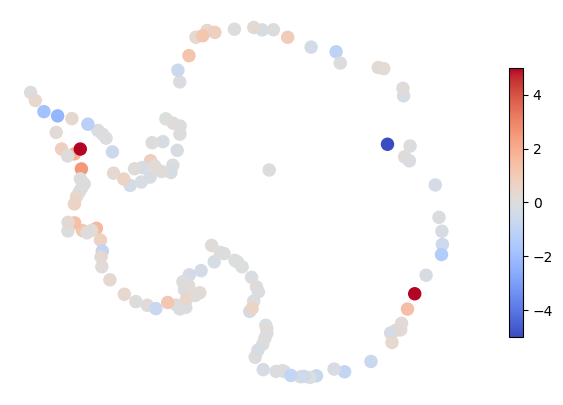

In [36]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
ref_bas = n1999.groupby(['basin']).sum()/12
ref_bas2 = n1999.groupby(['basin']).mean()
plt.scatter(ref_bas2.lon, ref_bas2.lat, c = ref_bas.melt_Gt_per_yr - ref_bas.melt_pred_Gt, \
            s = 75, cmap = 'coolwarm', transform = trans)
cbar = plt.colorbar(shrink = 0.7)
#cbar.set_label('Over predicting     Under predicting')
plt.clim(-5,5)
ax.axis('off')
plt.title('')


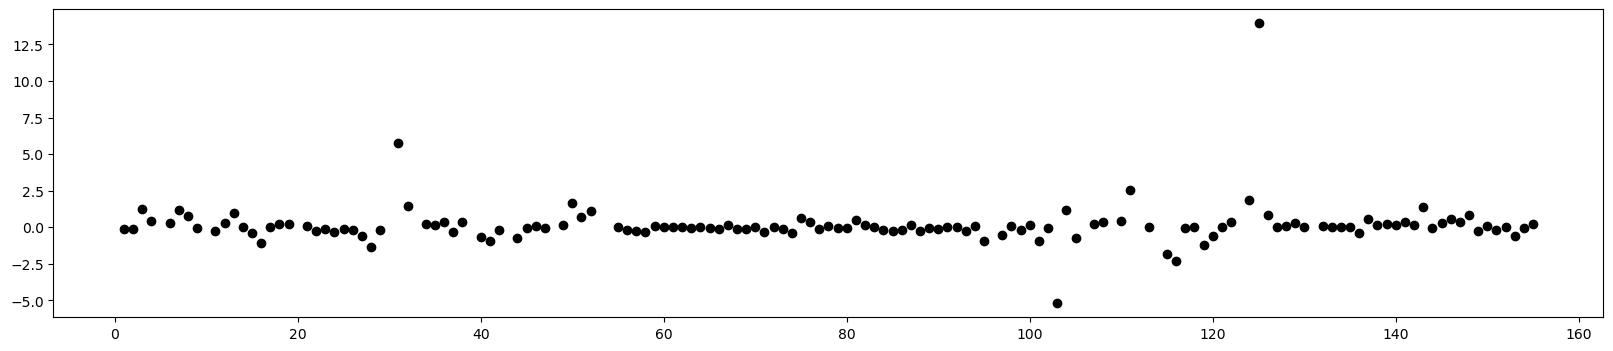

In [37]:
fig, ax = plt.subplots(1,1, figsize = (20,4))
plt.scatter(ref_bas.lat.index, ref_bas.melt_Gt_per_yr - ref_bas.melt_pred_Gt, c = 'k')

In [38]:
example = ref_pred[(ref_pred.basin == 103) & (ref_pred.year == 1999) & (ref_pred.month == 1)]

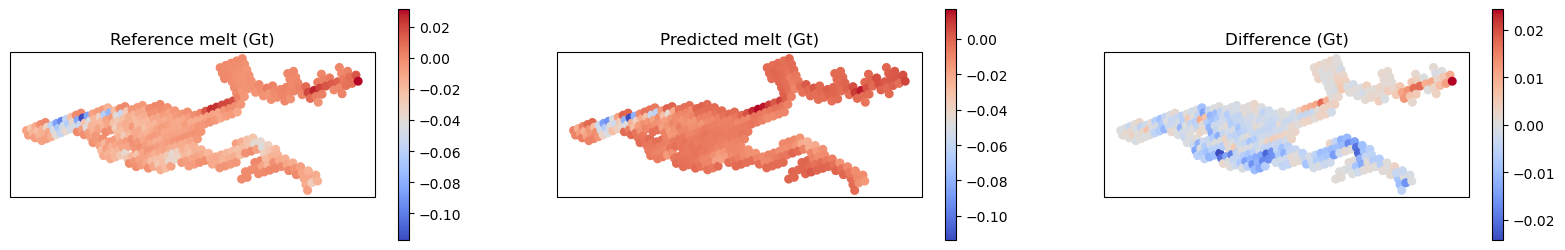

In [39]:
fig, ax = plt.subplots(1,3, figsize = (20,6), subplot_kw={'projection': proj})
im = [[],[],[]]
titles = 'Reference melt (Gt)', 'Predicted melt (Gt)', 'Difference (Gt)'
size = 30
im[0] = ax[0].scatter(example.lon, example.lat, c = example.melt_Gt_per_yr/12, cmap = 'coolwarm', transform = trans, s = size)
im[1] = ax[1].scatter(example.lon, example.lat, c = example.melt_pred_Gt/12, cmap = 'coolwarm', transform = trans, s= size)
im[2] = ax[2].scatter(example.lon, example.lat, c = (example.melt_Gt_per_yr-example.melt_pred_Gt)/12, cmap = 'coolwarm', 
                      transform = trans, s = size)
for i in range(3):
    plt.colorbar(im[i], ax = ax[i], shrink = 0.5)
    ax[i].set_title(titles[i])

Text(0.5, 1.0, 'Percentage Predicted/Reference')

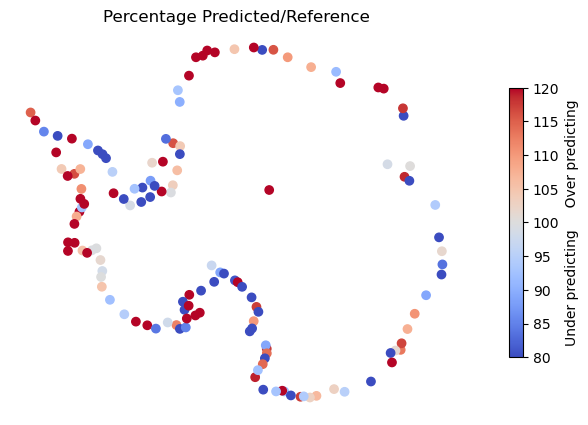

In [40]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
ref_bas = ref_pred.groupby(['basin']).sum()
ref_bas2 = ref_pred.groupby(['basin']).mean()
plt.scatter(ref_bas2.lon, ref_bas2.lat, c = ref_bas.melt_pred_Gt*100/ref_bas.melt_Gt_per_yr, cmap = 'coolwarm', transform = trans)
cbar = plt.colorbar(shrink = 0.7)
cbar.set_label('Under predicting     Over predicting')
plt.clim(80,120)
ax.axis('off')
plt.title('Percentage Predicted/Reference')


In [41]:
#basins = (0,20,40,60,80,100, 120, 110)
#for i in range(len(basins)):
#    basin = basins[i]
#    ref_basin = ref_pred[ref_pred.basin == basin]
#    ref_ym = ref_basin.groupby(['year', 'month']).sum()
#    slope, intercept, rsq = regression_analysis(ref_ym['melt_Gt_per_yr'].values, ref_ym['melt_pred_Gt'].values)

In [42]:
rsq_by_basin = np.ndarray(len(basins))
slopes_by_basin = np.ndarray(len(basins))
lats_by_basin = np.ndarray(len(basins))
lons_by_basin = np.ndarray(len(basins))
points = np.ndarray(len(basins))
for i in range(len(basins)):
    basin = basins[i]
    ref_basin = ref_pred[ref_pred.basin == basin]
    #ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
    ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
    points[i] = ref_bym.shape[0]
    ref_ym = ref_basin.groupby(['year', 'month']).sum()
    slope, intercept, rsq = regression_analysis(ref_ym['melt_Gt_per_yr'], ref_ym['melt_pred_Gt'])
    rsq_by_basin[i] = rsq 
    slopes_by_basin[i] = slope
    lats_by_basin[i] = np.mean(ref_basin.lat)
    lons_by_basin[i] = np.mean(ref_basin.lon)

/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 1979) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/3585696762.py:10: UserWarning: Boolean Series key

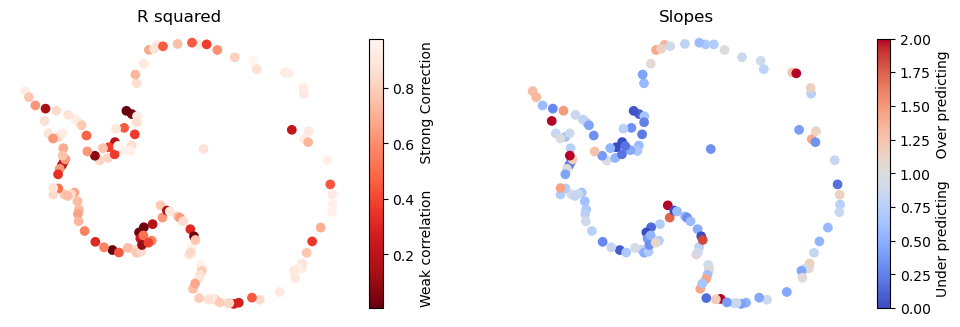

In [43]:
fig, ax = plt.subplots(1,2, figsize = (12,5), subplot_kw={'projection': proj})
im = [[],[]]
im[0] = ax[0].scatter(lons_by_basin, lats_by_basin, c = rsq_by_basin, transform = trans, cmap = 'Reds_r')
im[1] = ax[1].scatter(lons_by_basin, lats_by_basin, c = slopes_by_basin, transform = trans, cmap = 'coolwarm')

im[1].set_clim(0,2)
titles = 'R squared', 'Slopes'
labels = 'Weak correlation      Strong Correction', 'Under predicting     Over predicting'
for i in range(2):
    cbar = plt.colorbar(im[i], ax = ax[i], shrink = 0.7)
    cbar.set_label(labels[i])
    ax[i].axis('off')
    ax[i].set_title(titles[i])

In [44]:
bad_correlation = basins[rsq_by_basin < 0.2]
weird = basins[slopes_by_basin > 5]

bad_correlation, weird

(array([ 49.,  55.,  58.,  60.,  67.,  71.,  72.,  75.,  81.,  82., 116.,
        135., 148.]),
 array([19.]))

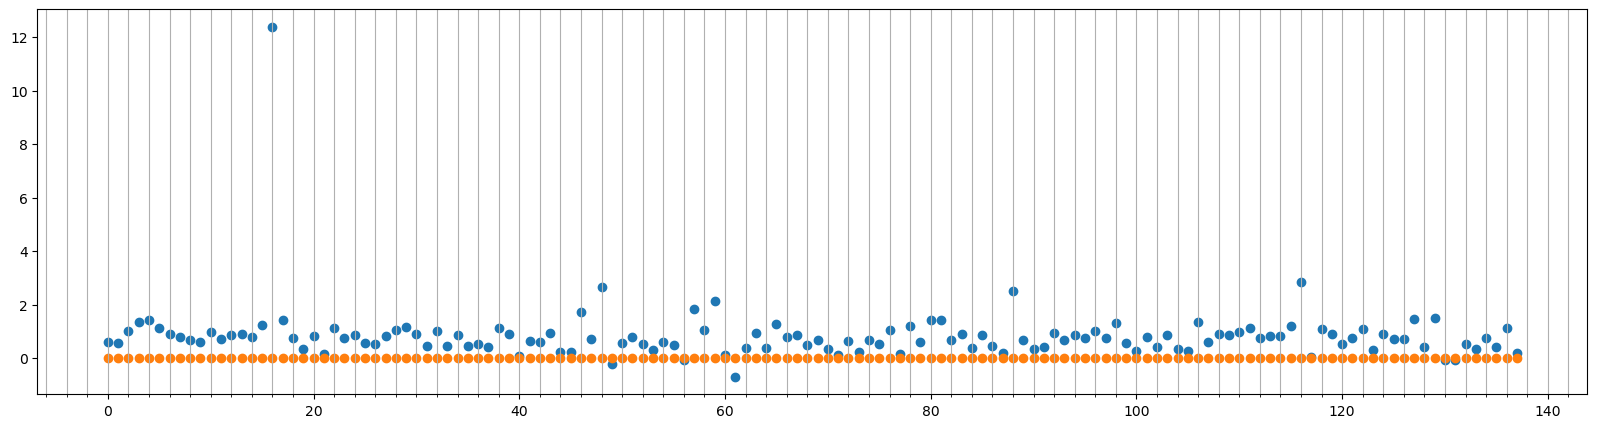

In [45]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
plt.scatter(range(len(basins)), slopes_by_basin)
plt.scatter(range(len(basins)), points/25)
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
plt.grid(axis = 'x', which  = 'minor', zorder= 0)
plt.grid(axis = 'x', which  = 'major', zorder = 0)

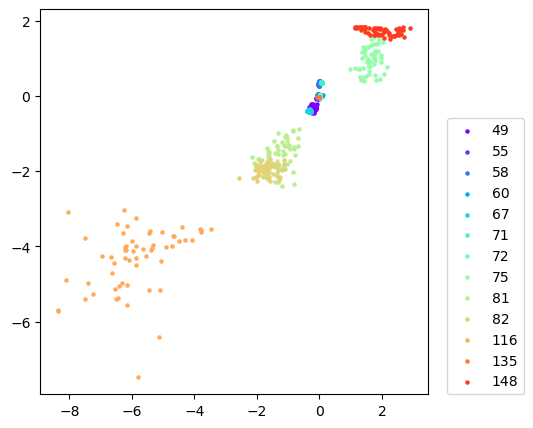

In [46]:
i = 3
c_a = 0
fig, ax = plt.subplots(1,1, figsize = (5,5))
for i in bad_correlation:
    i = int(i)
    ii = np.mod(int(i/20), 3)
    jj = int((int(i/20) - np.mod(int(i/20),3))/3)
    #for i in range(len(basins)):
    basin = i
    ref_basin = ref_pred[ref_pred.basin == basin]
    ref_ym = ref_basin.groupby(['year', 'month']).sum()
    ax.scatter(ref_ym.melt_Gt_per_yr.values, ref_ym.melt_pred_Gt.values, s = 5, color = plt.cm.rainbow(c_a/len(bad_correlation)), \
               label = '{}'.format(int(basin)))
    c_a = c_a + 1
    #ticks = np.arange(0,60,3)
    #ax.set_xticks(ticks)
    #ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
    #ax.set_ylabel('Integrated melt (Gt/y)', fontweight = 'bold')
    #ax.set_xlabel('Time', fontweight = 'bold')
ax.legend(loc = (1.05,0));
x_ample = np.linspace(-0.0001,0.0001,5)
ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')

In [47]:
ref_sm = ref_pred[(ref_pred.year == 2019) & (ref_pred.month == 1)]
#ref_sm = ref_pred[(ref_pred.year == 1979) & (ref_pred.month == 1)]

/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
/tmp/ipykernel_45625/1793435020.py:6: UserWarning: Boolean Series key will 

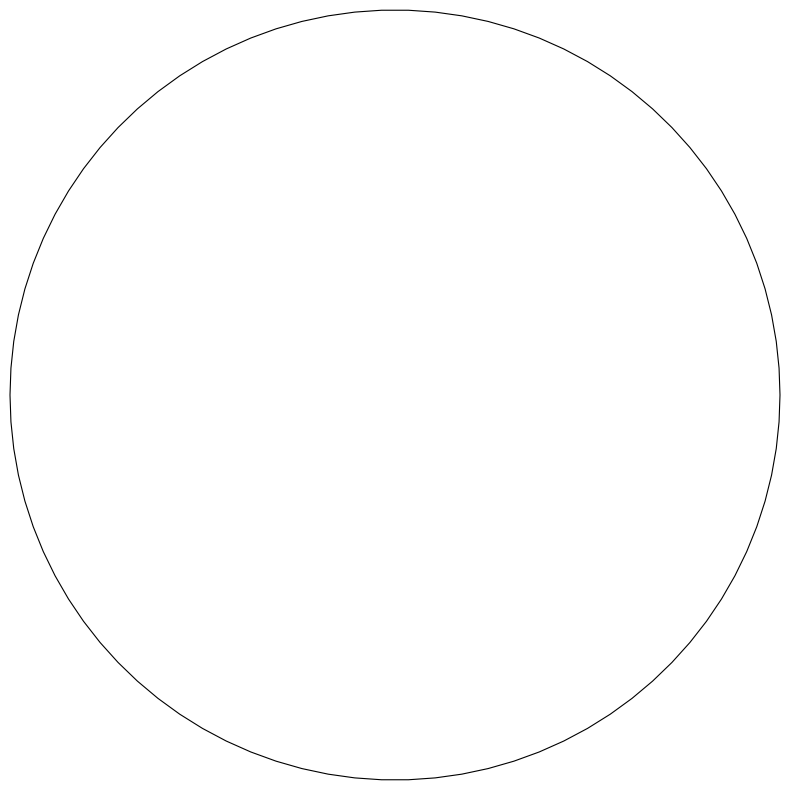

In [48]:
fig, ax_all = plt.subplots(1,1,figsize = (10,10), subplot_kw={'projection': proj})
plt.scatter(ref_sm.lon, ref_sm.lat, transform = trans, s = 1, color = 'grey')
for i in range(len(bad_correlation)):
    basin = bad_correlation[i]
    ref_basin = ref_pred[ref_pred.basin == basin]
    ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
    plt.scatter(ref_bym.lon, ref_bym.lat, transform = trans)
for i in range(len(weird)):
    basin = weird[i]
    ref_basin = ref_pred[ref_pred.basin == basin]
    ref_bym = ref_basin[(ref_pred.year == 2019) & (ref_pred.month == 1)]
    plt.scatter(ref_bym.lon, ref_bym.lat, transform = trans, color = 'k')

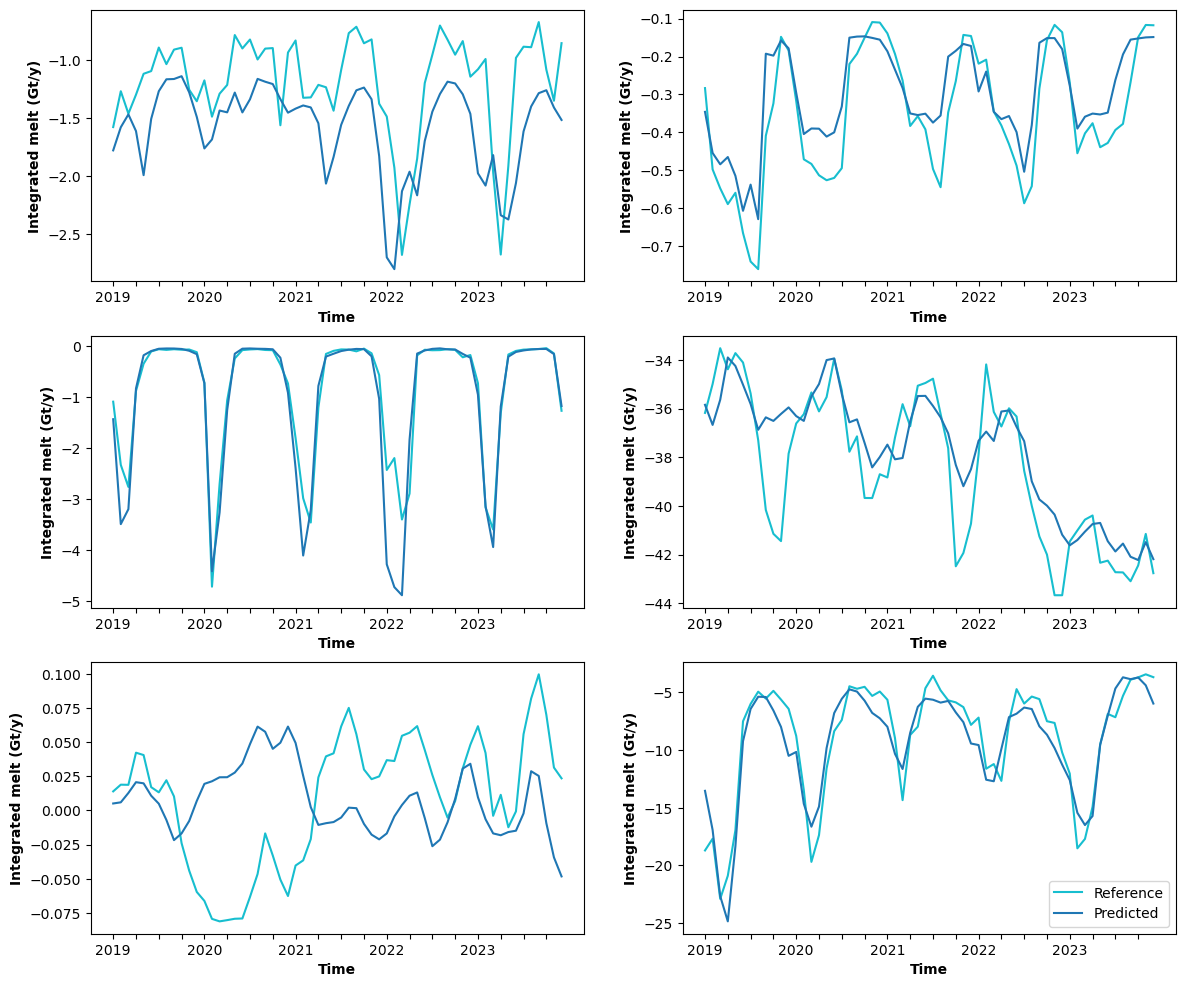

In [49]:
i = 9
fig, ax_all = plt.subplots(3,2, figsize = (14,12))
for i in (0,20,40,60,80,100):
    i = i + 9
    ii = np.mod(int(i/20), 3)
    jj = int((int(i/20) - np.mod(int(i/20),3))/3)
    ax = ax_all[ii,jj]
    #for i in range(len(basins)):
    basin = basins[i]
    ref_basin = ref_pred[ref_pred.basin == basin]
    ref_ym = ref_basin.groupby(['year', 'month']).sum()
    ax.plot(ref_ym.melt_Gt_per_yr.values, c = 'C9', label = 'Reference')
    ax.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
    ticks = np.arange(0,60,3)
    ax.set_xticks(ticks)
    ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
    ax.set_ylabel('Integrated melt (Gt/y)', fontweight = 'bold')
    ax.set_xlabel('Time', fontweight = 'bold')
ax.legend(loc = 0)
    

In [50]:
years = np.unique(ref_pred.year)
months = np.unique(ref_pred.month)

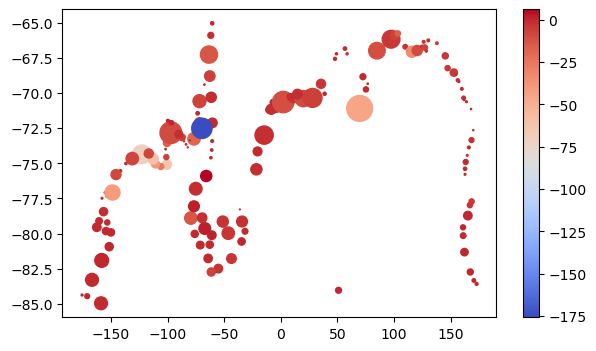

In [51]:
i = 3
j = 0
year = years[i]
month = months[j]
ref_ym = ref_pred[(ref_pred.year == year) & (ref_pred.month == month)]
ref_basin = ref_ym[['melt_pred_Gt', 'basin', 'melt_Gt_per_yr', 'area']].groupby('basin').sum()
ref_basin2 = ref_ym[['lat','lon', 'basin']].groupby('basin').mean()

fig, ax = plt.subplots(1,1, figsize = (7,4))
im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = ref_basin.area/100000000, c = ref_basin.melt_Gt_per_yr, cmap = 'coolwarm')
plt.colorbar(im, ax = ax)
#plt.clim(-0.006,0.006)
#im.set_clim(-0.0003,0.0003)

In [52]:
import cartopy.crs as ccrs
# For plotting things on the polar stereographic grid with lat and lon coordinates 
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()
# Remember to add transform=trans

In [53]:
months_names = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')

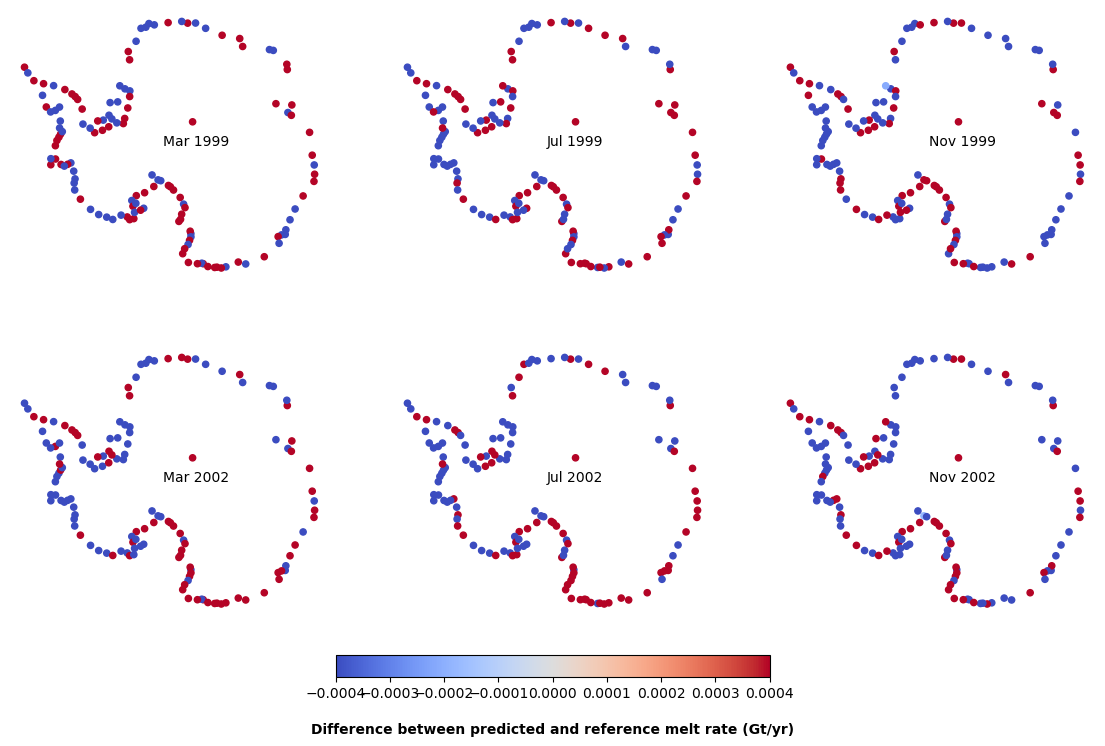

In [54]:
#fig, ax = plt.subplots(1,1, figsize = (7,5), subplot_kw={'projection': proj})
fig, ax_all = plt.subplots(2,3,figsize = (14,10), subplot_kw={'projection': proj})
for i in (0,3):
    for j in (0,4,8):
        ax = ax_all[int(i/2),int(j/4)]
        year = years[i]
        month = months[j+2]
        month_name = months_names[month-1]
        ref_ym = ref_pred[(ref_pred.year == year) & (ref_pred.month == month)]
        ref_basin = ref_ym[['melt_pred_Gt', 'basin', 'melt_Gt_per_yr', 'area']].groupby('basin').sum()
        ref_basin2 = ref_ym[['lat','lon', 'basin']].groupby('basin').mean()
        
        #im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = ref_basin.area/100000000, \
        #                c = ref_basin.melt_Gt_per_yr, \
        #                cmap = 'viridis', transform = trans)
        im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = 20, \
                        c = (ref_basin.melt_pred_Gt - ref_basin.melt_Gt_per_yr), \
                        cmap = 'coolwarm', transform = trans)
        #plt.colorbar(im, ax = ax)
        ax.annotate('{} {}'.format(month_name, year), xy = (0,0), xytext = (0,0))
        #im.set_clim(50,150)
        im.set_clim(-0.0004,0.0004)
        ax.axis('off')
cbar = plt.colorbar(im, ax = ax_all, shrink = 0.4, orientation = 'horizontal', pad = 0.05)
cbar.set_label('\nDifference between predicted and reference melt rate (Gt/yr)', fontweight = 'bold')

In [55]:
ref_ym

,lat,lon,basin,area,year,month,melt_m_ice_per_y,melt_01,melt_02,melt_03,melt_04,melt_05,melt_06,melt_07,melt_08,melt_09,melt_10,melt_pred_mean,melt_Gt_per_yr,melt_pred_Gt
521410,-85.396736,-152.77846,59.0,1.690724e+07,2002,11,-2.542083e-06,-0.000011,-3.255642e-06,2.601555e-07,-4.846661e-07,3.692836e-06,3.150304e-06,7.791823e-08,-0.000007,2.700297e-06,-2.239827e-06,-0.000001,-0.001355,-0.000775
521411,-85.368385,-154.12903,59.0,1.702015e+07,2002,11,-7.958459e-08,-0.000002,-5.467995e-06,7.573548e-06,9.308365e-06,4.652102e-07,-6.416340e-07,-4.636131e-07,0.000002,6.085662e-06,1.505032e-07,0.000002,-0.000043,0.000913
521412,-85.365005,-153.69621,59.0,1.700046e+07,2002,11,-5.501312e-06,-0.000010,-2.912097e-06,-1.677381e-06,-5.400849e-06,-1.036413e-06,-4.013229e-06,-5.827387e-07,-0.000004,-2.802357e-06,-3.582976e-06,-0.000004,-0.002949,-0.001920
521413,-85.361430,-153.26420,59.0,1.698055e+07,2002,11,-5.415502e-06,-0.000009,-3.286739e-06,-2.735105e-07,-5.423924e-06,-3.510493e-06,-3.645742e-06,-1.075772e-06,-0.000002,-2.554323e-06,-4.416684e-06,-0.000004,-0.002900,-0.001913
521414,-85.357635,-152.83304,59.0,1.696043e+07,2002,11,-1.864406e-06,0.000003,-5.060829e-06,-2.512508e-06,-1.470180e-06,-2.535489e-06,-4.675130e-06,-2.236819e-06,0.000001,5.593756e-08,-3.404941e-06,-0.000002,-0.000997,-0.000957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532740,-65.078710,97.00000,26.0,1.372189e+08,2002,11,-5.734580e-06,-0.000013,-1.297368e-05,-1.727157e-05,-1.420897e-05,-1.511164e-05,-1.221752e-05,-1.228614e-05,-0.000024,-1.795622e-05,-2.367465e-05,-0.000016,-0.024815,-0.070332
532741,-65.078710,-60.75000,113.0,1.372189e+08,2002,11,-1.535191e-05,-0.000030,-6.775779e-06,-7.484312e-06,-9.231935e-06,-1.475863e-05,-1.390711e-05,-1.633520e-05,-0.000021,-1.488147e-05,-1.736082e-05,-0.000015,-0.066433,-0.065625
532742,-65.078710,-60.50000,113.0,1.372189e+08,2002,11,-1.071218e-05,-0.000006,-9.473260e-06,-1.567983e-05,-7.402097e-06,-8.124040e-06,-6.213599e-06,-1.444347e-05,-0.000011,-1.157979e-05,-1.164299e-05,-0.000010,-0.046355,-0.043560
532743,-64.973160,-60.75000,113.0,1.383087e+08,2002,11,-9.928636e-06,-0.000014,8.608731e-07,3.433055e-06,2.818095e-06,1.121976e-05,-8.791812e-06,-5.216745e-06,-0.000014,-1.117549e-05,-1.175756e-05,-0.000005,-0.043306,-0.020399


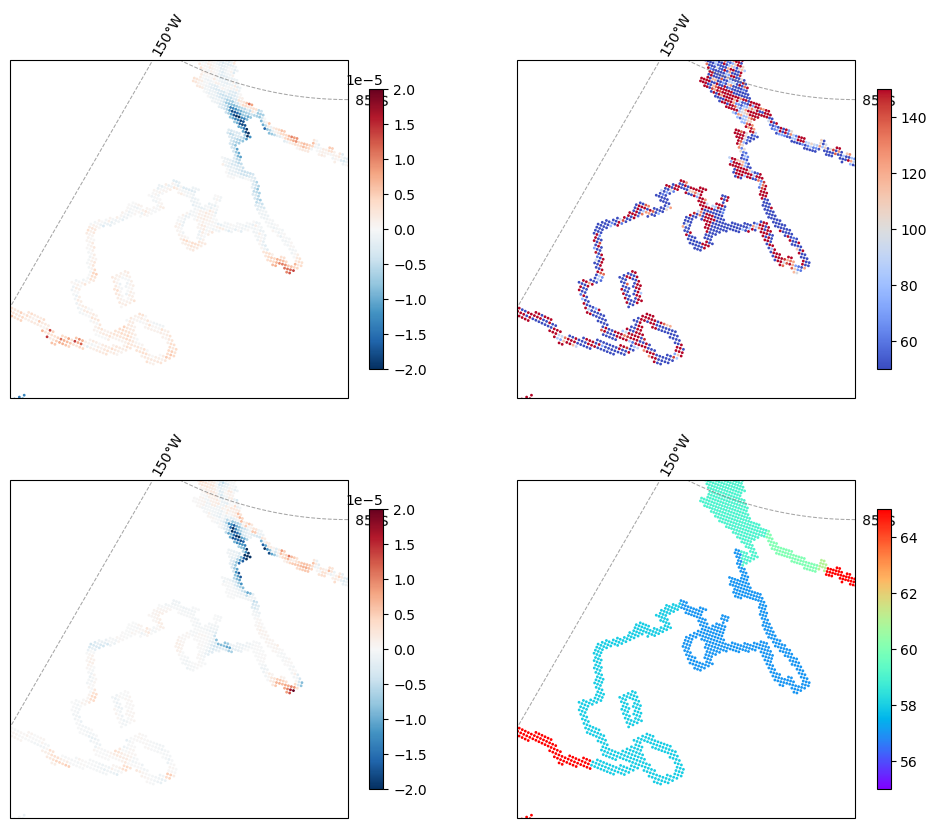

In [56]:
fig, axs_all = plt.subplots(2,2, figsize = (12,10), subplot_kw={'projection': proj} )
plts = ref_ym.melt_pred_mean, ref_ym.melt_m_ice_per_y, ref_ym.melt_pred_mean*100/ref_ym.melt_m_ice_per_y, ref_ym.basin
cmaps = ('RdBu_r', 'RdBu_r', 'coolwarm', 'rainbow')
for i in range(4):
    axs = axs_all[np.mod(i,2), int((i - np.mod(i,2))/2)]
    im = axs.scatter(ref_ym.lon, ref_ym.lat, c = (plts[i]), cmap = cmaps[i], transform = trans, s = 1)
    if i == 3:
        im.set_clim(55,65)
    elif i == 2:
        im.set_clim(50,150)
    else:
        im.set_clim(-0.00002,0.00002)
    plt.colorbar(im, ax = axs, shrink = 0.8)
    
    gl0 = axs.gridlines(draw_labels=True, linewidth=0.75, color='gray', alpha=0.7, linestyle='--',
                           dms=True, x_inline=False, y_inline=False )
    import matplotlib.ticker as mticker
    gl0.xlocator = mticker.FixedLocator(np.arange(-180,210,30))
    gl0.ylocator = mticker.FixedLocator(np.arange(-90,-50,5))
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    gl0.xformatter = LongitudeFormatter()
    gl0.yformatter = LatitudeFormatter()
    
    bounds = [-0.5e6,0e6,-1e6,-0.5e6]
    axs.set_xlim(bounds[0], bounds[1])
    axs.set_ylim(bounds[2], bounds[3])